In [1]:
import os
from pathlib import Path
from typing import Tuple
import warnings

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
MIN_AUDIO_DURATION = 10  # [s]
MAX_AUDIO_DURATION = 30  # [s]

In [3]:
PROJECT_DIR = Path(os.environ['PROJECT_DIR'])
RAW_DATA_PATH = PROJECT_DIR / 'data/raw_data'
PREPROCESSED_DATA_PATH = PROJECT_DIR / 'data/preprocessed_data'

In [4]:
if not PREPROCESSED_DATA_PATH.exists():
    PREPROCESSED_DATA_PATH.mkdir(parents=True)

In [5]:
from pandas.errors import SettingWithCopyWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

In [6]:
lables_paths = RAW_DATA_PATH.rglob('*split.csv')
labels = pd.DataFrame({'split': []})
for path in sorted(lables_paths):
    labels = pd.concat([labels, pd.read_csv(path)], axis=0)
    labels.fillna(path.stem.split('_')[0], inplace=True)
labels.columns = [c.lower() for c in labels.columns]

# fill missing values (there are two of them) in the 'PTSD Severity' column with its median depending on binary  PCL-C score
labels['ptsd severity'][labels['ptsd severity'] == 'test'] = labels[labels['ptsd severity'] == 'test'].apply(
    lambda row: labels['ptsd severity'][(labels['ptsd severity'] != 'test') & (labels['pcl-c (ptsd)'] == row['pcl-c (ptsd)'])].median(),
    axis=1
)

# clean the 'gender' label
labels['gender'] = labels['gender'].apply(str.strip)

In [7]:
for label in ['gender', 'phq_binary', 'phq_score', 'pcl-c (ptsd)', 'ptsd severity']:
    print(f'{label}:', labels[label].unique())

gender: ['male' 'female']
phq_binary: [0. 1.]
phq_score: [ 2.  3.  0.  8. 11. 20.  5.  7.  9. 16. 12. 17.  6. 10. 18.  4.  1. 19.
 13. 22. 15. 21. 23. 14.]
pcl-c (ptsd): [0. 1.]
ptsd severity: [25.0 17.0 21.0 51.0 64.0 62.0 61.0 32.0 29.0 26.0 56.0 52.0 54.0 43.0
 40.0 19.0 49.0 46.0 41.0 27.0 20.0 36.0 72.0 30.0 18.0 22.0 39.0 23.0
 31.0 28.0 55.0 44.0 60.0 67.0 37.0 81.0 35.0 68.0 24.0 71.0 42.0 66.0
 58.5 58.0 70.0 53.0 77.0 73.0 74 33 50 85 59 45 48 63 34 75]


In [8]:
transcripts_paths = RAW_DATA_PATH.rglob('*Transcript.csv')
transcripts = pd.DataFrame({'id': []})
for path in sorted(transcripts_paths):
    transcripts = pd.concat([transcripts, pd.read_csv(path)], axis=0)
    transcripts.fillna(int(path.stem.split('_')[0]), inplace=True)
transcripts.columns = [c.lower() for c in transcripts.columns]

In [9]:
transcripts['words_cnt'] = transcripts['text'].apply(lambda text: len(text.strip().split()))
transcripts['duration'] = transcripts.apply(lambda row: row['end_time'] - row['start_time'], axis=1)

In [10]:
filtered_transcripts = transcripts[(transcripts['duration'] > 10) & (transcripts['duration'] < 30) & (transcripts['words_cnt'] > 10)]
f"Total patients preserved: {100 * len(set(filtered_transcripts['id'].unique())) / len(labels):.2f}%"

'Total patients preserved: 89.45%'

In [11]:
f"{filtered_transcripts['duration'].sum() / 3600:.2f}h of recodrings in total"

'14.11h of recodrings in total'

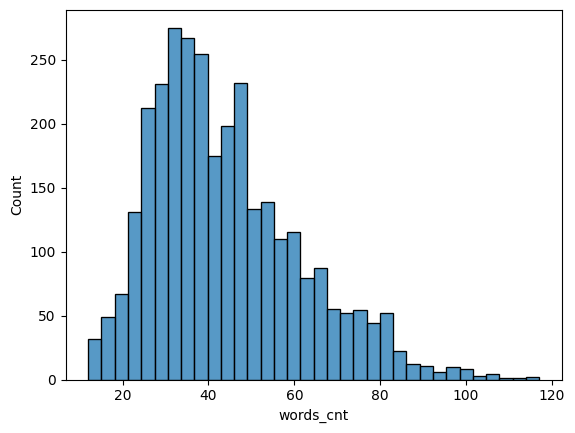

In [12]:
sns.histplot(filtered_transcripts['words_cnt'])
plt.show()

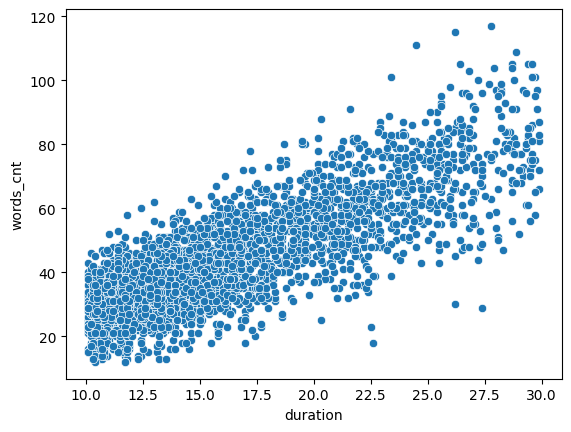

In [13]:
sns.scatterplot(data=filtered_transcripts, x='duration', y='words_cnt')
plt.show()

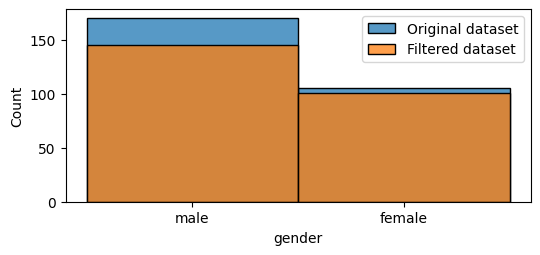

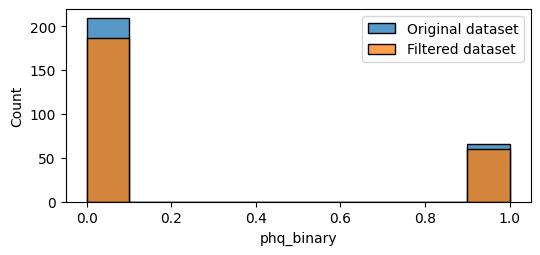

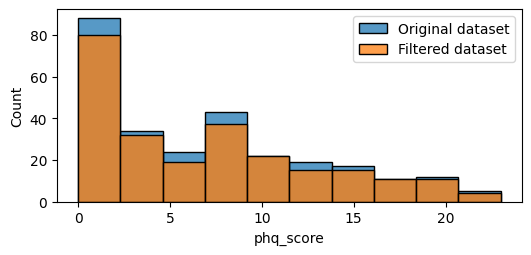

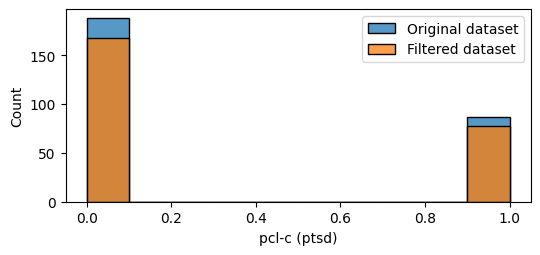

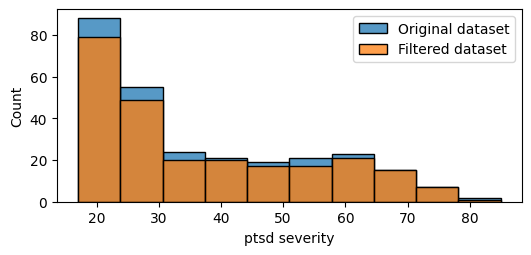

In [14]:
for label in ['gender', 'phq_binary', 'phq_score', 'pcl-c (ptsd)', 'ptsd severity']:
    plt.figure(figsize=(6, 2.5))
    sns.histplot(labels[label], bins=10, label='Original dataset')
    sns.histplot(labels[label][labels['participant_id'].isin(filtered_transcripts['id'].unique())], bins=10, label='Filtered dataset')
    plt.legend()
    plt.show()

In [15]:
df = filtered_transcripts.merge(
    labels, 
    left_on='id', 
    right_on='participant_id', 
    validate='m:1'
).reset_index(drop=True)
df.drop('id', axis=1, inplace=True)
df['source'] = df['participant_id'].apply(
    lambda p_id: (RAW_DATA_PATH / f'{int(p_id)}_P/{int(p_id)}_AUDIO.wav').as_posix()
)

In [16]:
df.split.value_counts() / len(df)

split
train    0.655459
dev      0.187000
test     0.157541
Name: count, dtype: float64

In [17]:
df.to_csv(PREPROCESSED_DATA_PATH / 'data.csv', index=False)